In [1]:
df = pd.read_csv(r"\Users\Anjli Kumari\campusx-lectures\datasets\Iris.csv")

In [2]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df = df.iloc[:,1:]

In [4]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
enc = LabelEncoder()

In [9]:
df['Species'] = enc.fit_transform(df['Species'])

In [13]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [14]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

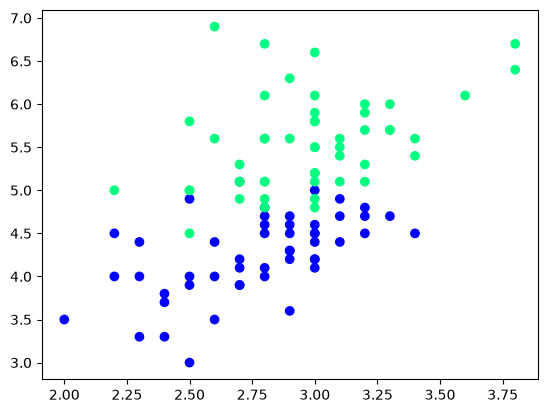

In [17]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [18]:
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80 ,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [21]:
df_train

,SepalWidthCm,PetalLengthCm,Species
144,3.3,5.7,2
138,3.0,4.8,2
64,2.9,3.6,1
131,3.8,6.4,2
78,2.9,4.5,1
103,2.9,5.6,2
104,3.0,5.8,2
53,2.3,4.0,1
65,3.1,4.4,1
55,2.8,4.5,1


In [22]:
X_test = df_val.iloc[:,0:2].values
Y_test = df_val.iloc[:,-1].values

### Case 1 - Bagging

In [54]:
# Tree 1
df_bag1 = df_train.sample(8,replace=True)
X = df_bag1.iloc[:,0:2]
Y = df_bag1.iloc[:,-1]

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [41]:
dct_bag1 = DecisionTreeClassifier()
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(Y_test,y_pred))

In [37]:
dct_bag1.fit(X,Y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

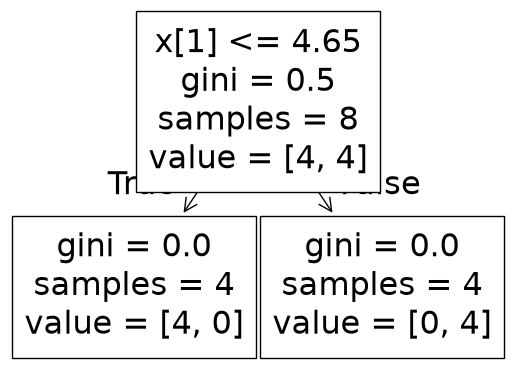

C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


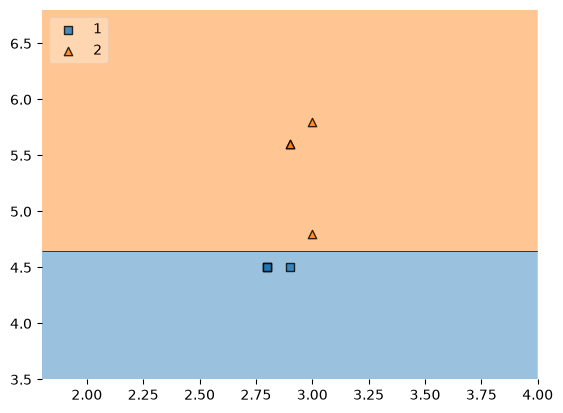

In [42]:
evaluate(dct_bag1,X,Y)

In [48]:
# Tree 2
df_bag2 = df_train.sample(8,replace=True)
X = df_bag2.iloc[:,0:2]
Y = df_bag2.iloc[:,-1]

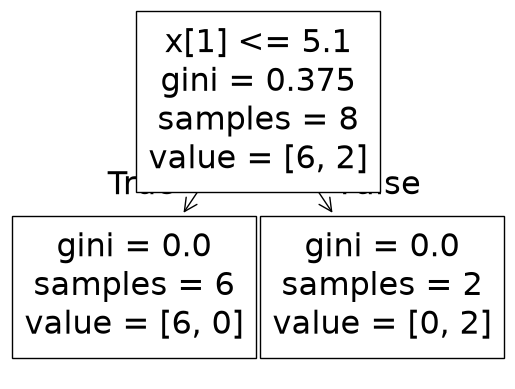

C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


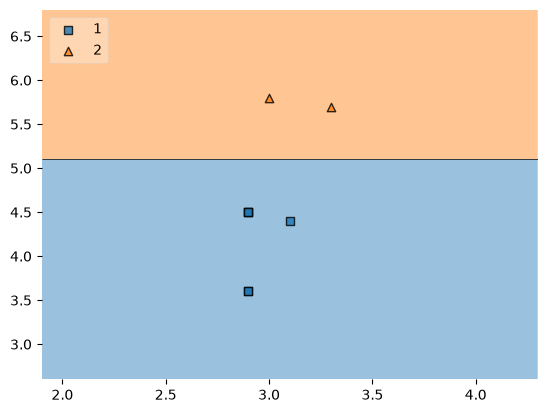

In [50]:
dct_bag2 = DecisionTreeClassifier()
dct_bag2.fit(X,Y)
evaluate(dct_bag2,X,Y)

In [45]:
# Tree 3
df_bag3 = df_train.sample(8,replace=True)
X = df_bag3.iloc[:,0:2]
Y = df_bag3.iloc[:,-1]

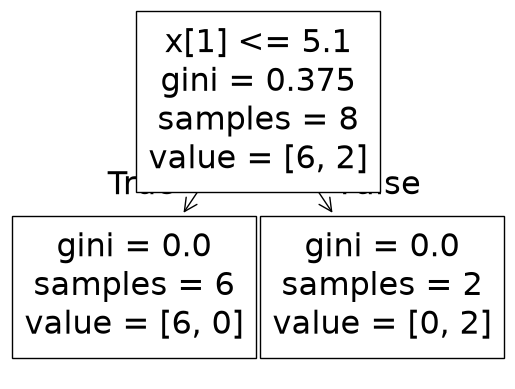

C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


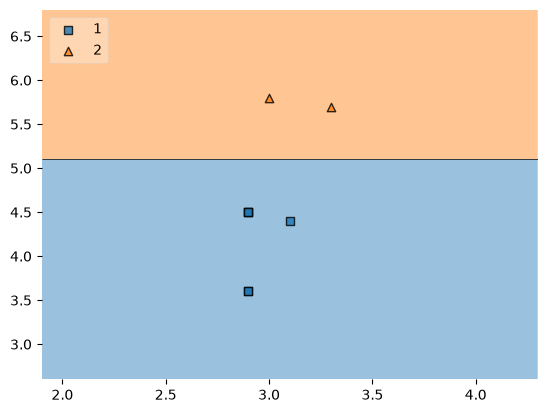

In [51]:
dct_bag3 = DecisionTreeClassifier()
dct_bag3.fit(X,Y)
evaluate(dct_bag3,X,Y)

### Testing

In [52]:
df_test

,SepalWidthCm,PetalLengthCm,Species
108,2.5,5.8,2
124,3.3,5.7,2
52,3.1,4.9,1
117,3.8,6.7,2
146,2.5,5.0,2


In [61]:
print("Predictor 1",dct_bag1.predict(np.array([3.1,5.0]).reshape(1,2)))
print("Predictor 2",dct_bag2.predict(np.array([3.1,5.0]).reshape(1,2)))
print("Predictor 3",dct_bag3.predict(np.array([3.1,5.0]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [1]
Predictor 3 [1]


C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Anjli Kumari\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


### Pasting

In [62]:
df_train

,SepalWidthCm,PetalLengthCm,Species
144,3.3,5.7,2
138,3.0,4.8,2
64,2.9,3.6,1
131,3.8,6.4,2
78,2.9,4.5,1
103,2.9,5.6,2
104,3.0,5.8,2
53,2.3,4.0,1
65,3.1,4.4,1
55,2.8,4.5,1


In [63]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
65,3.1,4.4,1
53,2.3,4.0,1
131,3.8,6.4,2
78,2.9,4.5,1
55,2.8,4.5,1
144,3.3,5.7,2
138,3.0,4.8,2
103,2.9,5.6,2


### Random Subspaces

In [64]:
df1 = pd.read_csv(r"\Users\Anjli Kumari\campusx-lectures\datasets\Iris.csv")

In [65]:
df1 = df1.sample(10)

In [68]:
df1.sample(2,replace=True,axis=1)

,Id,PetalLengthCm
149,150,5.1
61,62,4.2
41,42,1.3
63,64,4.7
145,146,5.2
39,40,1.5
89,90,4.0
110,111,5.1
86,87,4.7
75,76,4.4


In [70]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,SepalWidthCm,SepalWidthCm
75,3.0,3.0
75,3.0,3.0
63,2.9,2.9
63,2.9,2.9
145,3.0,3.0
149,3.0,3.0
63,2.9,2.9
61,3.0,3.0


### Demos

In [1]:
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

In [2]:
X,Y = make_classification(n_samples=10000,n_features=10,n_informative=3)

In [3]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [4]:
dct = DecisionTreeClassifier(random_state=42)
dct.fit(X_train,Y_train)
Y_pred = dct.predict(X_test)
print("Decision Tree Accuracy:",accuracy_score(Y_test,Y_pred))

Decision Tree Accuracy: 0.9275


### Bagging Demo

In [88]:
bag = BaggingClassifier(estimator=DecisionTreeClassifier(),
                        n_estimators=500,max_samples=0.25,bootstrap=True,random_state=42)

In [89]:
bag.fit(X_train,Y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",500
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.25
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [90]:
Y_pred = bag.predict(X_test)

In [91]:
accuracy_score(Y_test,Y_pred)

0.939

In [92]:
bag.estimators_samples_[0].shape

(2000,)

In [93]:
bag.estimators_features_[0].shape

(10,)

### Bagging Using SVM

In [94]:
bag = BaggingClassifier(estimator=SVC(),
                        n_estimators=500,max_samples=0.25,bootstrap=True,random_state=42)

In [100]:
import time
start = time.time()
print("Executing")
bag.fit(X_train,Y_train)
print("Time Taken:{}".format(time.time()-start))

Executing
Time Taken:63.78961730003357


In [102]:
import time
start = time.time()
print("Executing")
Y_pred = bag.predict(X_test)
print("Time Taken:{}".format(time.time()-start))

Executing
Time Taken:142.06725907325745


In [107]:
print("Bagging Using SVM:",accuracy_score(Y_test,Y_pred))

Bagging Using SVM: 0.9005


In [103]:
bag.estimators_features_[0].shape

(10,)

In [104]:
bag.estimators_samples_[0].shape

(2000,)

### Pasting

In [111]:
bag = BaggingClassifier(estimator=DecisionTreeClassifier(),
                        n_estimators=500,max_samples=0.25,bootstrap=False,random_state=42,verbose=1,n_jobs=-1)

In [112]:
import time
start = time.time()
print("Executing")
bag.fit(X_train,Y_train)
print("Time Taken:{}".format(time.time()-start))

Executing


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   2 out of  12 | elapsed:   15.1s remaining:  1.3min


Time Taken:17.086710929870605


[Parallel(n_jobs=12)]: Done  12 out of  12 | elapsed:   17.0s finished


In [113]:
Y_pred = bag.predict(X_test)
print("Accuracy Using Pasting:",accuracy_score(Y_test,Y_pred))

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   2 out of  12 | elapsed:    0.0s remaining:    0.6s


Bagging Using Pasting: 0.9365


[Parallel(n_jobs=12)]: Done  12 out of  12 | elapsed:    0.4s finished


### Random SubSpaces

In [115]:
bag = BaggingClassifier(estimator=DecisionTreeClassifier(),
                        n_estimators=500,max_samples=1.0,bootstrap=False,max_features=0.5,
                        bootstrap_features=True,random_state=42)

In [116]:
bag.fit(X_train,Y_train)
Y_pred = bag.predict(X_test)

In [118]:
print("Accuracy Using Random SubSpaces:",accuracy_score(Y_test,Y_pred))

Bagging Using Random SubSpaces: 0.936


In [119]:
bag.estimators_samples_[0].shape

(8000,)

In [121]:
bag.estimators_features_[0].shape

(5,)

### Random Patches

In [123]:
bag = BaggingClassifier(estimator=DecisionTreeClassifier(),
                        n_estimators=500,max_samples=0.25,bootstrap=True,max_features=0.5,
                        bootstrap_features=True,random_state=42)

In [124]:
bag.fit(X_train,Y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",500
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.25
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",0.5
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [125]:
Y_pred = bag.predict(X_test)

In [134]:
print("Accuracy Using Random Patches:",accuracy_score(Y_test,Y_pred))

Accuracy Using Random Patches: 0.939


### OOB Score

In [129]:
bag = BaggingClassifier(estimator=DecisionTreeClassifier(),
                        n_estimators=500,max_samples=0.25,bootstrap=True,oob_score=True,random_state=42)

In [131]:
bag.fit(X_train,Y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",500
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.25
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [132]:
bag.oob_score_

0.936

In [133]:
Y_pred = bag.predict(X_test)

In [135]:
print("Accuracy:",accuracy_score(Y_test,Y_pred))

Accuracy: 0.939


### Bagging Tips
#### Bagging generally gives better results than Pasting
#### Good results come around the 25% to 50% row sampling mark
#### Random patches and subspaces should be used while dealing with high dimensional data
#### To find the correct hyperparameter values we can do GridSearchCV/RandomSearchCV

### Applying GridSearchCV

In [5]:
from sklearn.model_selection import GridSearchCV

In [6]:
parameters = {
    'n_estimators':[50,100,500],
    'max_samples':[0.1,0.4,0.7,1.0],
    'bootstrap':[True,False],
    'max_features':[0.1,0.4,0.7,1.0]
    }

In [7]:
search = GridSearchCV(BaggingClassifier(),parameters,cv=5)

In [8]:
import time
start = time.time()
print("Executing")
search.fit(X_train,Y_train)
print("Time Taken:{}".format(time.time()-start))

Executing
Time Taken:4758.263947963715


In [10]:
search.best_params_

{'bootstrap': True,
 'max_features': 0.7,
 'max_samples': 1.0,
 'n_estimators': 100}

In [11]:
search.best_score_

np.float64(0.9570000000000001)

### Bagging-Regressor

In [14]:
from sklearn.datasets import fetch_california_housing

In [15]:
housing  = fetch_california_housing()

In [17]:
X_housing,Y_housing = housing.data,housing.target
print("Dataset Features Names:" + str(housing.feature_names))
print("Datset Features Size:" + str(housing.data.shape))
print("Dataset Target Size:" + str(housing.target.shape))

Dataset Features Names:['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Datset Features Size:(20640, 8)
Dataset Target Size:(20640,)


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train,X_test,Y_train,Y_test = train_test_split(X_housing,Y_housing,train_size=0.8,test_size=0.2,random_state=123)

In [21]:
print("Train/Test Sets Size:",X_train.shape,X_test.shape,Y_train.shape,Y_test.shape)

Train/Test Sets Size: (16512, 8) (4128, 8) (16512,) (4128,)


In [25]:
lr = LinearRegression()
dt = DecisionTreeRegressor()
knn = KNeighborsRegressor()

In [26]:
lr.fit(X_train,Y_train)
dt.fit(X_train,Y_train)
knn.fit(X_train,Y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [28]:
Y_pred1 = lr.predict(X_test)
Y_pred2 = dt.predict(X_test)
Y_pred3 = knn.predict(X_test)

In [29]:
print("R-2 Score For LR:",r2_score(Y_test,Y_pred1))
print("R-2 Score For DT:",r2_score(Y_test,Y_pred2))
print("R-2 Score For KNN:",r2_score(Y_test,Y_pred3))

R-2 Score For LR: 0.6104546894797869
R-2 Score For DT: 0.6072453732953523
R-2 Score For KNN: 0.16261917827057237


In [30]:
from sklearn.ensemble import BaggingRegressor

bag_regressor = BaggingRegressor(random_state=1)
bag_regressor.fit(X_train,Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",1
,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeRegressor`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",10
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [32]:
Y_preds = bag_regressor.predict(X_test)
print("Training Coefficient Of R-2: %.3f"%bag_regressor.score(X_train,Y_train))
print("Test Coefficient Of R-2: %.3f"%bag_regressor.score(X_test,Y_test))

Training Coefficient Of R-2: 0.963
Test Coefficient Of R-2: 0.794


In [39]:
%%time

n_samples = housing.data.shape[0]
n_features = housing.data.shape[1]

params = {
    'estimator': [None, LinearRegression(), KNeighborsRegressor()],
    'n_estimators': [20,50,100],
    'max_samples': [0.5,1.0],
    'max_features': [0.5,1.0],
    'bootstrap': [True,False],
    'bootstrap_features': [True,False]}

bagging_regressor_grid = GridSearchCV(BaggingRegressor(random_state=1,n_jobs=-1),param_grid=params,
                                      cv=3,n_jobs=1,verbose=1)
bagging_regressor_grid.fit(X_train,Y_train)
print("Train R-2 Score: %.3f"%bagging_regressor_grid.best_estimator_.score(X_train,Y_train))
print("Train R-2 Score: %.3f"%bagging_regressor_grid.best_estimator_.score(X_test,Y_test))
print("Train R-2 Score: %.3f"%bagging_regressor_grid.best_score_)
print("Best Prameters: ",bagging_regressor_grid.best_params_)

Fitting 3 folds for each of 144 candidates, totalling 432 fits
Train R-2 Score: 0.973
Train R-2 Score: 0.815
Train R-2 Score: 0.801
Best Prameters:  {'bootstrap': True, 'bootstrap_features': True, 'estimator': None, 'max_features': 1.0, 'max_samples': 1.0, 'n_estimators': 100}
CPU times: total: 4min 1s
Wall time: 12min 32s
